# Automated Customer Reviews
### Goal:
The goal is to create a NLP powered web application that aggregates and analyzes customer reviews.

### Main Functionality:
1. **Classification**: Classify reviews into categories such as positive, negative, and neutral.
    - Use a model if i feel like it, but I can also use a simple keyword-based approach for a baseline.
        - if model, then use pre-trained transformer-based model

2. **Product Category Clustering**: Simplify dataset by clustering product categories into broader groups.
    - Use a clustering algorithm like K-means or hierarchical clustering on product features.

3. **Review Summarization using LLMs**: Summarize reviews into articles that recoment top products in each category.
    - Use a pre-trained LLM (T5, Bart, or Groq) for summarisation.
    - Find top complaints and worst features for each product category and worst individual products.
    - Can also generate sentiment-based summaries and sentiment analysis reports as bonus features.


In [2]:
# imports
import pandas as pd
import os

# Classification:
0. **Data Loading**: Load the dataset of Amazon product reviews.
1. **Data Cleaning and Preprocessing**: Handle missing values, clean review text, and perform tokenization.
2. **Feature Extraction**: Convert text data into numerical features using techniques like TF-IDF or word embeddings.

## Data Source:
- **Local Dataset**: Kaggle dataset of Amazon product reviews (small subset for testing)

In [3]:
if not os.path.exists("data"):
    import kagglehub, shutil
    shutil.move(
        kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products"),
        os.path.join(os.getcwd(), "data"))

100%|██████████| 16.3M/16.3M [00:02<00:00, 7.66MB/s]

Extracting files...


In [4]:
curr_dir = os.getcwd()

revs_df = pd.read_csv(os.path.join(curr_dir, "data", "1429_1.csv"))

revs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

/tmp/ipykernel_1108/1540874626.py:3: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  revs_df = pd.read_csv(os.path.join(curr_dir, "data", "1429_1.csv"))


## Data Cleaning and Preprocessing:
1. **Handling Missing Values**: Remove or impute missing values in the dataset.
2. **Text Preprocessing**: Clean review text by removing special characters, stop words, and performing tokenization.

In [5]:
useless_cols = [
    'id',
    'reviews.id', # not useful in our case
    'reviews.username', # might be useful for user-level analysis later
    'reviews.userCity', # might be useful for geographic analysis later
    'reviews.userProvince', # ^
    'manufacturer', # useless cuz all products are from the same manufacturer
    'reviews.sourceURLs',
    'keys',
    'asins', # not useful in our case
    'reviews.dateAdded',
    'reviews.dateSeen',
    'reviews.date',
    'reviews.didPurchase', # useless cuz only one value is True
]

In [6]:
def clean_data(df:pd.DataFrame, drop_cols:list=[]) -> pd.DataFrame:
    # Drops columns specified
    df_clean = df.drop(columns=drop_cols, errors="ignore").dropna(subset=["reviews.text", "reviews.rating"])

    # Drops rows that have NaN in these cols
    df_clean.dropna(subset=["name", "reviews.doRecommend"], inplace=True)

    # Replaces NaN values with False then
    df_clean.replace(pd.NA, False, inplace=True)

    # Make pd info work better
    df_clean["reviews.numHelpful"] = df_clean["reviews.numHelpful"].fillna(0).astype(int)
    df_clean["reviews.rating"] = df_clean["reviews.rating"].fillna(0).astype(int)
    df_clean["reviews.doRecommend"] = df_clean["reviews.doRecommend"].fillna(False).astype(bool)

    # Make sentiment column for classification
    def map_sentiment(rating):
      if rating >= 4:
          return "positive"
      elif rating == 3:
          return "neutral"
      else:
          return "negative"

    df_clean['reviews_sentiment'] = df_clean['reviews.rating'].map(map_sentiment)

    return df_clean

revs_df_clean = clean_data(revs_df, useless_cols)
revs_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27409 entries, 0 to 27899
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   name                 27409 non-null  object
 1   brand                27409 non-null  object
 2   categories           27409 non-null  object
 3   reviews.doRecommend  27409 non-null  bool  
 4   reviews.numHelpful   27409 non-null  int64 
 5   reviews.rating       27409 non-null  int64 
 6   reviews.text         27409 non-null  object
 7   reviews.title        27409 non-null  object
 8   reviews_sentiment    27409 non-null  object
dtypes: bool(1), int64(2), object(6)
memory usage: 1.9+ MB


/tmp/ipykernel_1108/2358444216.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean.replace(pd.NA, False, inplace=True)


In [7]:
revs_df_clean.sample(10)

,name,brand,categories,reviews.doRecommend,reviews.numHelpful,reviews.rating,reviews.text,reviews.title,reviews_sentiment
19060,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Amazon,"Walmart for Business,Office Electronics,Tablet...",True,0,4,I am very satisfied with this new Kindle. I ha...,Love this Kindle,positive
19379,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Amazon,"Walmart for Business,Office Electronics,Tablet...",True,0,5,I love reading on my Paperwhite! The battery l...,Great device!,positive
7104,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",True,0,4,It's alright personally the picture quality is...,Good,positive
17513,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Amazon,"Walmart for Business,Office Electronics,Tablet...",True,0,5,This replaced my 5 year old keyboard unit whic...,Great replacement,positive
5393,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",False,0,3,I ended up returning it after 15 days. The bro...,It's not bad for the price,neutral
17522,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Amazon,"Walmart for Business,Office Electronics,Tablet...",True,2,5,Great alternative to an internet connected/gam...,Kids can't surf the web/play games with this!,positive
11584,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",True,0,5,"I bought 3 of these for my mom, MIL and 6 year...",Great tablet,positive
19606,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Amazon,"Walmart for Business,Office Electronics,Tablet...",True,0,5,I purchased this kindle for my daughter inlaw ...,Great Kindle,positive
1522,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",True,0,5,Bought two of these for my kids for Christmas....,Great bang for your buck,positive
11245,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",True,0,5,"Kids love it, no real issues. Solid tablet for...",great little tablet,positive


### Classification Model:

In [8]:
from transformers import pipeline
import torch

classifier = pipeline(
                      task="text-classification",
                      model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
                      device=0,          # GPU
                      truncation=True,
                      max_length=512
                      )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [9]:
rand_revs = revs_df_clean[["reviews.title", "reviews.text", "reviews_sentiment"]]

rand_revs['review_input'] = rand_revs['reviews.title'].fillna('').replace(False, '') + '. ' + rand_revs['reviews.text'].fillna('')
rand_revs['review_input'] = rand_revs['review_input'].str.strip()

rand_revs

/tmp/ipykernel_1108/868034416.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rand_revs['review_input'] = rand_revs['reviews.title'].fillna('').replace(False, '') + '. ' + rand_revs['reviews.text'].fillna('')
/tmp/ipykernel_1108/868034416.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rand_revs['review_input'] = rand_revs['review_input'].str.strip()


,reviews.title,reviews.text,reviews_sentiment,review_input
0,Kindle,This product so far has not disappointed. My c...,positive,Kindle. This product so far has not disappoint...
1,very fast,great for beginner or experienced person. Boug...,positive,very fast. great for beginner or experienced p...
2,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,positive,Beginner tablet for our 9 year old son.. Inexp...
3,Good!!!,I've had my Fire HD 8 two weeks now and I love...,positive,Good!!!. I've had my Fire HD 8 two weeks now a...
4,Fantastic Tablet for kids,I bought this for my grand daughter when she c...,positive,Fantastic Tablet for kids. I bought this for m...
...,...,...,...,...
27895,My new favorite product,This is my new favorite device. While not perf...,positive,My new favorite product. This is my new favori...
27896,Lots of potential!!!,I got this to basically experiment with. Strai...,positive,Lots of potential!!!. I got this to basically ...
27897,Good First Generation Product,Good product that does the basics. Too bad you...,positive,Good First Generation Product. Good product th...
27898,"Great for a ""connected home""",This is great for a connected home. People who...,neutral,"Great for a ""connected home"". This is great fo..."


In [11]:
# GPU enhanced run
sentiment = {}
results = classifier(rand_revs['review_input'].tolist(), batch_size=64)

for text, result in zip(rand_revs['review_input'], results):
    sentiment[text[:40]] = [result['label'], result['score']]

In [12]:
# # normal run
# sentiment = {}
# for a in rand_revs['review_input']:
#   sentiment[a[:40]] = list(classifier(a)[0].values())

In [16]:
from numpy import average
sents = []
for a in list(sentiment.values()):
  sents.append(a[1])
print(f'Average confidence for the set: {round(average(sents),2)}')
sentiment

Average confidence for the set: 0.98


{'Kindle. This product so far has not disa': ['POSITIVE', 0.9996243715286255],
 'very fast. great for beginner or experie': ['POSITIVE', 0.9998339414596558],
 'Beginner tablet for our 9 year old son..': ['POSITIVE', 0.9985159039497375],
 "Good!!!. I've had my Fire HD 8 two weeks": ['POSITIVE', 0.9998138546943665],
 'Fantastic Tablet for kids. I bought this': ['POSITIVE', 0.997265100479126],
 'Just what we expected. This amazon fire ': ['POSITIVE', 0.9973416924476624],
 'great e-reader tablet. Great for e-readi': ['POSITIVE', 0.9998340606689453],
 'Great for gifts. I gave this as a Christ': ['POSITIVE', 0.9998812675476074],
 'Great for reading. Great as a device to ': ['POSITIVE', 0.9995917677879333],
 'Great and lightweight reader. I love ord': ['POSITIVE', 0.9996939897537231],
 'nice tablet for the price. Not easy for ': ['NEGATIVE', 0.8491215109825134],
 'Excellent product. Excellent product. Ea': ['POSITIVE', 0.9998072981834412],
 'Great Value. Wanted my father to have hi': ['POSITI

### Visuals

In [20]:
y_results = []
for result in list(sentiment.values()):
  y_results.append(result[0])

y_test = rand_revs['reviews_sentiment'].tolist()

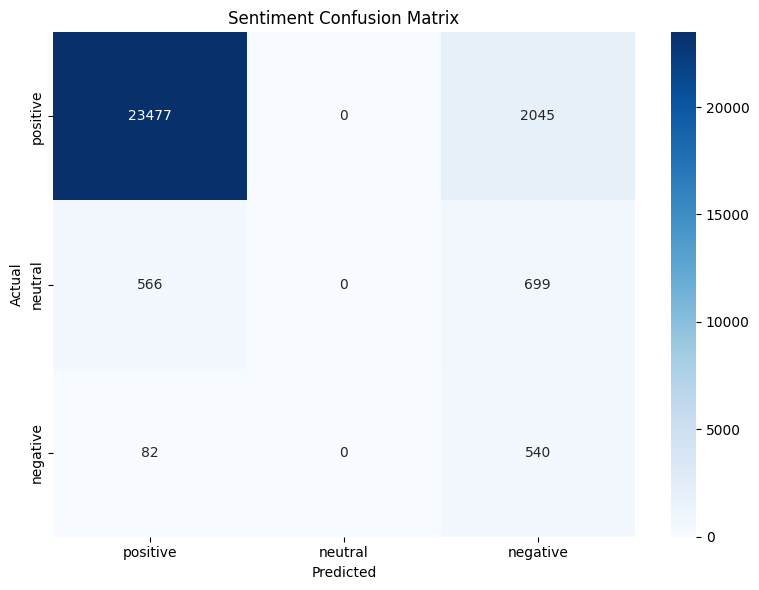

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# get predicted labels (normalize to match your mapped labels)
label_map = {'positive': 'positive', 'negative': 'negative', 'neutral': 'neutral'}
predicted = [label_map[r['label'].lower()] for r in results]
actual = revs_df_clean['reviews_sentiment'].tolist()

labels = ['positive', 'neutral', 'negative']
cm = confusion_matrix(actual, predicted, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Sentiment Confusion Matrix')
plt.tight_layout()
plt.show()